In [2]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d,gaussian_filter
import pickle
from skimage import io, filters
import glob
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import psutil
from brainsss import brain_utils

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [3]:
fly_num = 'fly_209'

i_path = 'temp_filter/whole_brain_interp.h5'
# dff_path = 'dff/functional_channel_2_moco_warp_blurred_hpf_dff.h5'

func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'

i_dir = os.path.join(func_path, i_path)
# dff_dir = os.path.join(func_path, dff_path)


In [4]:
%%time
with h5py.File(i_dir, 'r') as hf:
        brain = hf['brain'][:]
        ts = hf['time_stamps'][:]
        dimsb = np.shape(brain)
        dimst = np.shape(ts)
print(f"Brain shape is {dimsb}, time stamp shape is {dimst}")

Brain shape is (314, 146, 91, 100), time stamp shape is (314, 146, 91, 100)
CPU times: user 194 µs, sys: 1.83 s, total: 1.83 s
Wall time: 16.5 s


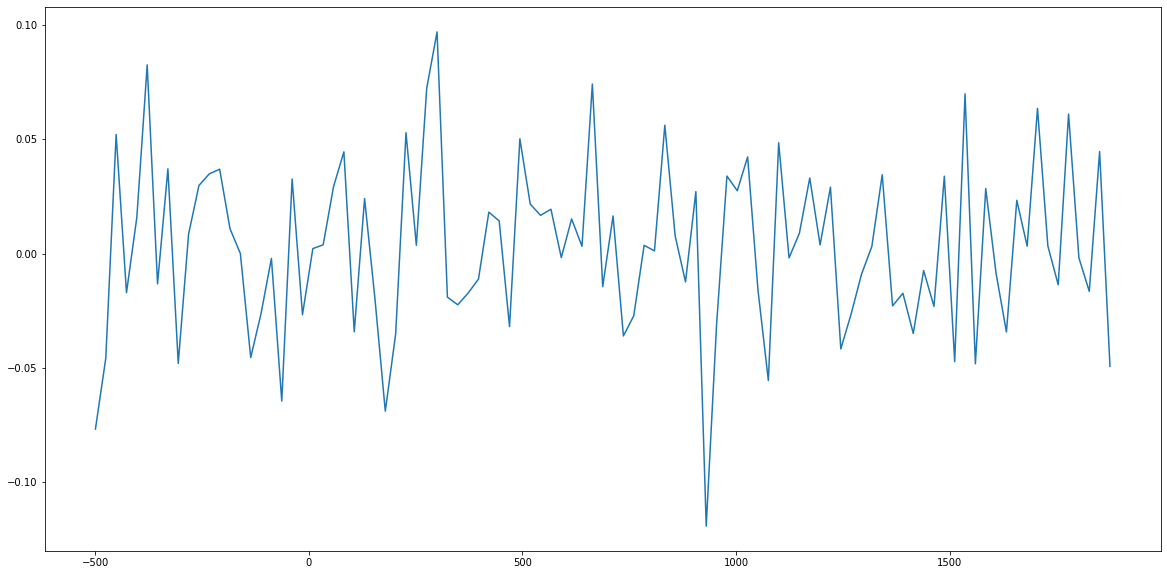

In [21]:
plt.figure(figsize=(20,10))
plt.plot(ts[100,40,20,:],brain[100,40,20,:])

In [6]:
STA_brain = np.nan_to_num(brain)
STA_brain = gaussian_filter1d(STA_brain,sigma=1,axis=1,truncate=1)

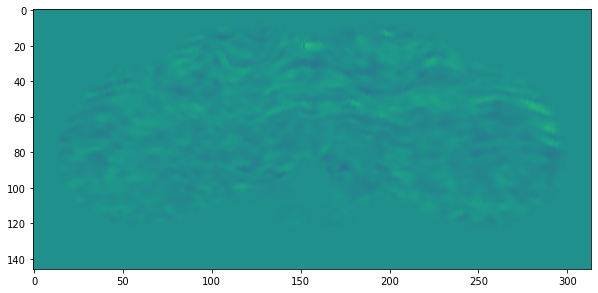

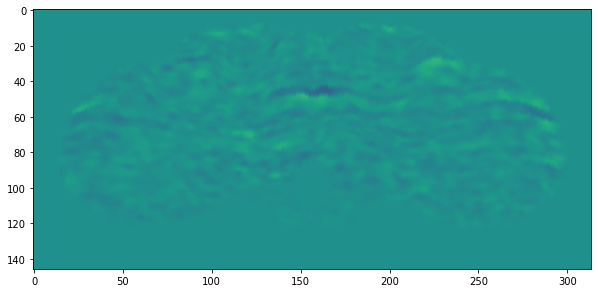

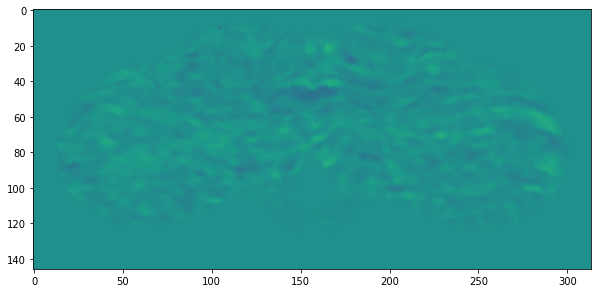

In [37]:
# fig, axs = plt.subplots(20,5)
# fig.figsize=(20,20)
# for x in range(5):
#     for y in range(20):
#         for i in range(dimsb[-1]):
#             axs[y,x].imshow(np.mean(STA_brain[:,:,:,i],axis=-1).T)
# ax.imshow(np.mean(STA_brain[:,:,20,:],axis=-1).T)
plt.figure(figsize=(10,10))
plt.imshow(STA_brain[...,20,40].T, vmax=0.5, vmin=-0.5)
plt.figure(figsize=(10,10))
plt.imshow(STA_brain[...,20,50].T, vmax=0.5, vmin=-0.5)
plt.figure(figsize=(10,10))
plt.imshow(STA_brain[...,20,60].T, vmax=0.5, vmin=-0.5)

In [30]:
STA_new=np.moveaxis(STA_brain, -1,0)

In [34]:
np.shape(STA_new)

(100, 314, 146, 91)

In [31]:
movie_dir = os.path.join(func_path, 'movies')
if os.path.exists(movie_dir)==False:
    os.mkdir(movie_dir)
print(movie_dir)

save_dir = os.path.join(movie_dir,'interp')
if os.path.exists(save_dir)==False:
    os.mkdir(save_dir)
print(save_dir)

/oak/stanford/groups/trc/data/Ilana/2P/data/fly_209/movies
/oak/stanford/groups/trc/data/Ilana/2P/data/fly_209/movies/interp


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


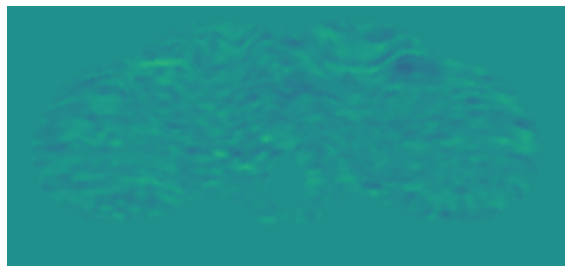

In [38]:
plt.figure(figsize=(10,10))
for i in range(20):
    print(i)
    plt.imshow(STA_new[i][:,:,20].T,vmax=0.5, vmin=-0.5) #this was made with cmap=hot
    plt.axis('off')
    fname = os.path.join(save_dir, '{0:05d}.png'.format(i))
    plt.savefig(fname,dpi=300,bbox_inches='tight')